# Herbaceous vegetation: data quality investigation

In [1]:
from geopy.distance import geodesic
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAW = "data/raw/Data Vegetation"
EXPORTS = f"{RAW}/ODK Data Exports"
ENTITIES = f"{RAW}/Entity lists"

# ODK form exports: one table per level of the survey
df_survey = pd.read_csv(f"{EXPORTS}/herbaceous_veg_survey.csv")
df_reg = pd.read_csv(f"{EXPORTS}/register_vegetation_plots.csv")                         # 1 row per registered plot
df_quadrat = pd.read_csv(f"{EXPORTS}/herbaceous_veg_survey-quadrat_repeat.csv")          # 20 rows per visit (as per SOP - quadrats along transect)
df_extra = pd.read_csv(f"{EXPORTS}/herbaceous_veg_survey-additional_species_repeat.csv") # off-list species

# Entity lists (lookups)
df_survey_entities = pd.read_csv(f"{ENTITIES}/surveys.csv")      # survey definitions
df_centroids = pd.read_csv(f"{ENTITIES}/centroids.csv")          # planned plot locations
df_vegplots = pd.read_csv(f"{ENTITIES}/vegplots.csv")            # registered plots
df_species = pd.read_csv(f"{ENTITIES}/species.csv")              # project species list
df_species_extra = pd.read_csv(f"{ENTITIES}/species_extra.csv")  # new + provisional species
df_team = pd.read_csv(f"{ENTITIES}/project_team.csv")

## a. Survey-level summary

In [2]:
df_survey_entities[df_survey_entities.target_group == "herbs"]

,__id,label,project_abbr,survey_type_label,area_label,target_group,baseline_year,project_label,target_parent_taxon,__createdAt,__creatorId,__creatorName,__updates,__updatedAt,__version
1,858076d3-1f5a-4aad-b9ad-1205828807e0,savmon|lw|herbs|ho,SAVMON,Human Observation,LW,herbs,2026,Savanna Monitoring Pilot,plants,2026-05-15T09:19:18.236Z,573,admin1@example.org,2,2026-05-15T09:24:30.430Z,3


In [3]:
# General metadata about the survey

survey_start = pd.to_datetime(df_survey["survey_begin-start_time"], utc=True)
team_names = df_team.set_index("__id")["label"]
team = df_survey["field_team_specifics-selected_project_team_uuid_multi"].str.split().explode().map(team_names)
survey_labels = df_survey["survey_begin-selected_survey_uuid"].map(df_survey_entities.set_index("__id")["label"])

pd.Series({
    "Survey": survey_labels.unique(),
    "Survey date range": f"{survey_start.min():%d %b} – {survey_start.max():%d %b %Y}",
    "Field days": survey_start.dt.date.nunique(),
    "Team": team.unique(),
    "Recorders": df_survey["field_team_specifics-recorder_uuid"].map(team_names).value_counts().to_dict(),
    "Submissions": len(df_survey),
    "Review state": df_survey["ReviewState"].fillna("accepted(?)").value_counts().to_dict(),
})

Survey                             [savmon|lw|herbs|ho]
Survey date range                  19 May – 27 May 2026
Field days                                            9
Team                              [Sam, Wanjiku, Grace]
Recorders                       {'Grace': 26, 'Sam': 6}
Submissions                                          32
Review state         {'accepted(?)': 30, 'rejected': 2}
dtype: object

In [4]:
# Link survey submissions to plots:
# survey -> vegplots (plot registered in the field) -> centroids (planned location)

plot_name = df_centroids.set_index("__id")["choice_name"]
df_survey["plot_id"] = df_survey["plot_selection-selected_plot_uuid"].map(df_vegplots.set_index("__id")["plot_uuid"])

planned = set(df_centroids.loc[df_centroids["sample_status"] == "primary", "__id"])
registered = set(df_vegplots["plot_uuid"])
viable = set(df_vegplots.loc[df_vegplots["is_viable"] == "yes", "plot_uuid"])
accepted = df_survey[df_survey["ReviewState"] != "rejected"]
surveyed = set(accepted["plot_id"])

names = lambda ids: sorted(plot_name[list(ids)])  # IDs -> names for printing

print("Planned locations:", len(df_centroids), "| primary:", len(planned), "| backup:", len(df_centroids) - len(planned))
print("Registered:", len(registered), "| of which backup:", names(registered - planned))
print("Not viable:", names(registered - viable))
print("Surveyed (accepted):", len(surveyed), "| of which primary:", len(surveyed & planned))
print()
print("Planned primary but never registered:", names(planned - registered))
print("Viable but not surveyed:", names(viable - surveyed))
print("Surveyed but not viable/registered:", names(surveyed - viable))

Planned locations: 51 | primary: 36 | backup: 15
Registered: 31 | of which backup: ['SavMon_LW_Plot_46']
Not viable: ['SavMon_LW_Plot_23']
Surveyed (accepted): 30 | of which primary: 29

Planned primary but never registered: ['SavMon_LW_Plot_31', 'SavMon_LW_Plot_32', 'SavMon_LW_Plot_33', 'SavMon_LW_Plot_34', 'SavMon_LW_Plot_35', 'SavMon_LW_Plot_36']
Viable but not surveyed: []
Surveyed but not viable/registered: []


In [5]:
# Check if rejected submissions are related to repeat visits

plot_counts = df_survey["plot_id"].value_counts()
duplicated_plots = plot_counts[plot_counts > 1].index

(df_survey.loc[df_survey["plot_id"].isin(duplicated_plots),
               ["plot_id", "survey_begin-start_time", "field_team_specifics-recorder_uuid", "ReviewState"]]
 .assign(plot_name=lambda d: d["plot_id"].map(plot_name),
         recorder=lambda d: d["field_team_specifics-recorder_uuid"].map(team_names))
 [["plot_name", "survey_begin-start_time", "recorder", "ReviewState"]]
 .sort_values(["plot_name", "survey_begin-start_time"]))

,plot_name,survey_begin-start_time,recorder,ReviewState
3,SavMon_LW_Plot_18,2026-05-26T08:23:51.656+02:00,Grace,NaN
5,SavMon_LW_Plot_18,2026-05-26T14:13:41.819+02:00,Grace,rejected
2,SavMon_LW_Plot_21,2026-05-26T09:44:02.068+02:00,Grace,NaN
1,SavMon_LW_Plot_21,2026-05-26T14:48:42.442+02:00,Sam,rejected


## b. Plot-level summary

In [6]:
# Build the species table: one row per species recorded in each quadrat, identified by species ID.
# Species are recorded in two places, so build each part and combine them.

# Project-list species: stored on each quadrat as space-separated species.__id values.
# Split them so each species gets its own row.

known = (
    df_quadrat[["KEY", "herb_species-selected_herb_species_uuids"]]
    .dropna()
    .assign(species_id=lambda d: d["herb_species-selected_herb_species_uuids"].str.split())
    .explode("species_id")
    .rename(columns={"KEY": "quadrat_key"})
)[["quadrat_key", "species_id"]]

# Additional (off-list) species: each entry stores the species_extra.__id it created (new species)
# or re-used (a species already added earlier). Only one of the three columns is filled per entry.
extra = pd.DataFrame({
    "quadrat_key": df_extra["PARENT_KEY"],
    "species_id": (df_extra["target_extra_name"]
                   .fillna(df_extra["select_reuse_missing"])
                   .fillna(df_extra["select_reuse_unknown"])),
})

df_obs = pd.concat([known.assign(source="project_list"), extra.assign(source="additional")], ignore_index=True)

# Look up each species' name (for display only), and mark unidentified placeholders (herb_XXX) as provisional
species_names = pd.concat([df_species.set_index("__id")["label"], df_species_extra.set_index("__id")["label"]])
df_obs["species_name"] = df_obs["species_id"].map(species_names)
df_obs["provisional"] = (df_obs["species_id"]
                         .map(df_species_extra.set_index("__id")["new_record_reason"]).eq("unknown_species"))

# Link each quadrat to its plot (quadrat -> survey -> plot_id)
quadrat_info = df_quadrat[["KEY", "PARENT_KEY", "quadrat_number"]].merge(
    df_survey[["KEY", "plot_id", "ReviewState"]],
    left_on="PARENT_KEY", right_on="KEY", suffixes=("", "_survey"),
).rename(columns={"KEY": "quadrat_key"})
# drop quadrats from rejected surveys
quadrat_info = quadrat_info[quadrat_info["ReviewState"] != "rejected"]

# Keep species records from accepted surveys only, and drop the one entry with no species selected
df_obs = df_obs.merge(quadrat_info[["quadrat_key", "plot_id", "quadrat_number"]], on="quadrat_key")
df_obs = df_obs.dropna(subset=["species_id"])

print("Species records:", len(df_obs))
print("Distinct species:", df_obs["species_id"].nunique(),
      "| of which provisional:", df_obs.loc[df_obs["provisional"], "species_id"].nunique())


Species records: 2092
Distinct species: 132 | of which provisional: 60


In [7]:
# plot summary table: one row per plot (accepted surveys only)

# Quadrats from accepted surveys, with their plot_id
quadrats_ok = df_quadrat.merge(quadrat_info[["quadrat_key", "plot_id"]], left_on="KEY", right_on="quadrat_key")

plot_summary = quadrats_ok.groupby("plot_id").agg(
    quadrats=("KEY", "size"),                                # should be 20 per plot (SOP)
    max_gps_accuracy_m=("location_quadrat-Accuracy", "max"), # should be <= 5 m (SOP)
).join(
    # Share of species records in each plot that are unidentified placeholders (herb_XXX)
    (df_obs.groupby("plot_id")["provisional"].mean() * 100).round(1).rename("pct_records_provisional")
)

# Add plot names for readability (plots are still identified by plot_id)
plot_summary.insert(0, "plot_name", plot_summary.index.map(plot_name))
plot_summary = plot_summary.sort_values("plot_name")
plot_summary


,plot_name,quadrats,max_gps_accuracy_m,pct_records_provisional
plot_id,,,,
1de06e5f-ffea-4859-a9ea-d8892e47a9bf,SavMon_LW_Plot_01,20,4.900,28.1
449006e8-3cda-4659-b7db-b892d3aa0320,SavMon_LW_Plot_02,20,3.600,44.0
810aa56e-e50a-44ab-9ab8-42d1552c349a,SavMon_LW_Plot_03,20,4.740,60.5
eab2feb8-72b1-491f-9223-ad5285d2d6db,SavMon_LW_Plot_04,20,4.750,48.1
68a92b1d-cd91-42f8-a4ac-582d2b2d3e30,SavMon_LW_Plot_05,20,4.560,23.3
6af30a65-e02d-41ca-ad67-c426c219db54,SavMon_LW_Plot_06,20,4.775,34.2
a9736eb5-344d-4615-8f2e-e73f38e4e124,SavMon_LW_Plot_07,20,4.950,45.3
1920716b-0cc6-42b0-8ebf-90ece20050df,SavMon_LW_Plot_08,20,5.000,29.1
0dc3e2bd-b285-42d5-b047-ac5172a3b61b,SavMon_LW_Plot_09,20,4.900,18.9


In [8]:
print("Plots without 20 quadrats:", (plot_summary["quadrats"] != 20).sum())
print("Worst quadrat GPS accuracy (m):", plot_summary["max_gps_accuracy_m"].max())

print("\nSummary of provisional species records across plots:")
plot_summary["pct_records_provisional"].agg(["median", "min", "max"]).round(1)


Plots without 20 quadrats: 0
Worst quadrat GPS accuracy (m): 5.0

Summary of provisional species records across plots:


median    29.6
min        9.3
max       73.7
Name: pct_records_provisional, dtype: float64

In [9]:
# Midpoint check: how far each registered plot's midpoint is from its planned location (SOP limit: 25 m).

# Planned position: centroids.geometry is an ODK geopoint "lat lon altitude accuracy"
planned = (df_centroids.set_index("__id")["geometry"]
           .str.split(expand=True).astype(float)
           .set_axis(["lat", "lon", "altitude", "accuracy"], axis=1))


# Registered midpoint, indexed by plot_id (the registration form stores centroids.__id)
mid = df_reg.set_index("plot_selection-selected_plot_uuid")[[
    "plot_metadata-collect_points-midpoint-location_midpoint-Latitude",
    "plot_metadata-collect_points-midpoint-location_midpoint-Longitude",
]].dropna()  # the non-viable plot has no midpoint recorded

# Distance in metres between each registered midpoint and its planned location
plot_summary["midpoint_shift_m"] = pd.Series({
        plot_id: geodesic((lat, lon), (planned.loc[plot_id, "lat"], planned.loc[plot_id, "lon"])).meters
    for plot_id, (lat, lon) in mid.iterrows()
}).round(1)

# Plots furthest from their planned location
plot_summary.sort_values("midpoint_shift_m", ascending=False).head(5)[["plot_name", "midpoint_shift_m"]]


,plot_name,midpoint_shift_m
plot_id,,
af3dc968-e531-4f35-894a-a57c843c3a9a,SavMon_LW_Plot_14,33.5
1d979a81-a11a-43de-85de-7367754879ba,SavMon_LW_Plot_17,23.8
b58271e9-c6d1-44f9-9286-0245b2e30a69,SavMon_LW_Plot_27,20.2
68a92b1d-cd91-42f8-a4ac-582d2b2d3e30,SavMon_LW_Plot_05,19.9
042bc8a0-b02c-4046-bd2e-4efb8a8d655d,SavMon_LW_Plot_22,17.7


In [10]:
# Species checks: data entry problems in the species records and the new-species list.

# Quadrats where the recorder said additional species were present, but none were entered
extra_missing = quadrats_ok[(quadrats_ok["additional_species_present"] == "yes")
                            & ~quadrats_ok["KEY"].isin(df_extra["PARENT_KEY"])]
print("Additional species = yes but none entered:", len(extra_missing), "quadrats in",
      extra_missing["plot_id"].nunique(), "plots")

# Additional-species entries with no species ID (nothing selected or created)
print("Entries with no species:", extra["species_id"].isna().sum())

# The next two checks compare names, so use the herbaceous entries in the new-species list (species_extra)
herb_extra = df_species_extra[df_species_extra["group_type"] == "herb"].assign(name=lambda d: d["label"].str.strip())

# Same species name created as two separate entries (two IDs, so counted as two species)
print("Created twice in species_extra:", sorted(herb_extra.loc[herb_extra["name"].duplicated(), "name"]))

# Created as a new ('missing') species although it is already on the project list
typed_in = herb_extra[herb_extra["new_record_reason"] == "missing_species"]
print("New species entry already on the list:", sorted(set(typed_in["name"]) & set(df_species["label"])))

# Typed names with stray spaces at the start or end
names_typed = df_extra["validated_name"].dropna()
print("Typed names with leading/trailing spaces:", (names_typed != names_typed.str.strip()).sum())

Additional species = yes but none entered: 9 quadrats in 7 plots
Entries with no species: 1
Created twice in species_extra: ['Aristida scabrivalvis', 'Justicia divaricata']
New species entry already on the list: ['Pechuel-loeschea leubnitziae']
Typed names with leading/trailing spaces: 64


## c. Sampling effort
**Accumulation curve:** species found as more quadrats (or plots) are added, averaged over random orders.
If it flattens, extra sampling finds little new; if it is still rising, more species remain to be found.
Summarised as **new species added by the final 5 quadrats** (per plot) and by the final 5 plots (project).
Empty quadrats are included as they are still sampling effort.

In [11]:
def species_sets(obs: pd.DataFrame, unit: str, all_units) -> list[set]:
    """The set of species IDs found in each unit (quadrat or plot); an empty set if none were found."""
    # Group the species records by unit and collect each unit's species IDs into a set
    found = obs.groupby(unit)["species_id"].agg(set)
    # Return one set per unit, in the order given. Units with no species records (empty quadrats)
    # aren't in `found`, so they get an empty set: they still count as sampling effort.
    return [found.get(u, set()) for u in all_units]


def accumulation_curve(species_by_unit: list[set], n_orders: int = 200, seed: int = 0) -> np.ndarray:
    """Average number of species found after 1, 2, ... units, over random orders of the units."""
    rng = np.random.default_rng(seed)  # fixed seed, so results are the same on every run
    curves = []

    # The shape of a single curve depends on which units happen to come first,
    # so build many curves from random orders and average them
    for _ in range(n_orders):
        seen = set()  # species found so far in this order
        curve = []    # number of species found after 1, 2, ... units
        for i in rng.permutation(len(species_by_unit)):  # visit the units in a random order
            seen.update(species_by_unit[i])               # add this unit's species to those seen so far
            curve.append(len(seen))                       # number of species found so far
        curves.append(curve)

    # Average across all the orders: element k is the expected number of species after k units
    return np.mean(curves, axis=0)


Project: 132 species observed; the final 5 plots add 8.7


count    30.0
mean      2.5
std       0.9
min       0.6
25%       1.9
50%       2.6
75%       3.2
max       4.5
Name: new_in_last_5_quadrats, dtype: float64

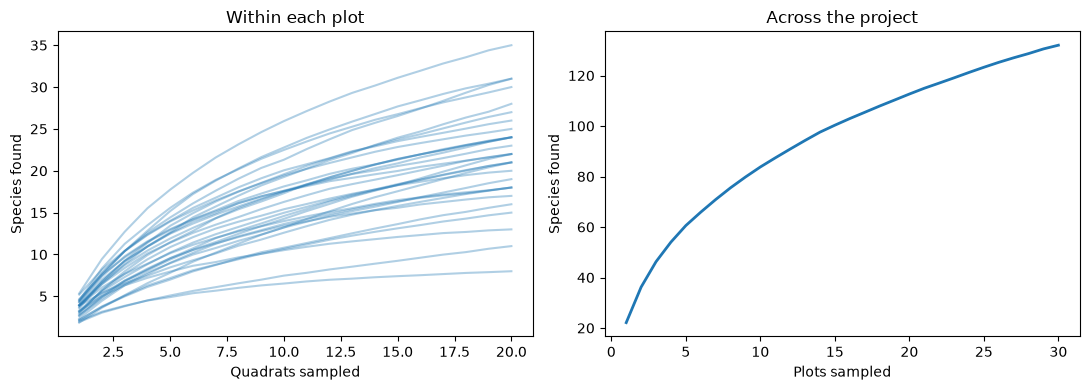

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Within each plot: quadrats are the sampling units (20 per plot)
new_in_last_5 = {}
for plot_id, obs_plot in df_obs.groupby("plot_id"):
    # All of this plot's quadrats, including any with no species, so the curve covers all 20
    plot_quadrats = quadrats_ok.loc[quadrats_ok["plot_id"] == plot_id, "KEY"]
    quadrat_species = species_sets(obs_plot, "quadrat_key", plot_quadrats)
    curve = accumulation_curve(quadrat_species)

    # How many new species the final 5 quadrats added: species after 20 quadrats minus after 15.
    new_in_last_5[plot_id] = curve[-1] - curve[-6]

    ax1.plot(range(1, len(curve) + 1), curve, color="C0", alpha=0.35)  # one faint line per plot
ax1.set(xlabel="Quadrats sampled", ylabel="Species found", title="Within each plot")
plot_summary["new_in_last_5_quadrats"] = pd.Series(new_in_last_5).round(1)

# Across the project: plots are the sampling units. A species counts as present in a plot
# if it was found in any of that plot's quadrats.
plot_species = species_sets(df_obs, "plot_id", sorted(df_obs["plot_id"].unique()))
curve = accumulation_curve(plot_species)
ax2.plot(range(1, len(curve) + 1), curve, lw=2)
ax2.set(xlabel="Plots sampled", ylabel="Species found", title="Across the project")
fig.tight_layout()

# Total species across all plots (union of every plot's set), and the project-level final-5 measure
print(f"Project: {len(set().union(*plot_species))} species observed; the final 5 plots add {curve[-1] - curve[-6]:.1f}")

# Summary of the final-5 measure across the 30 plots (median and range quoted in the report)
plot_summary["new_in_last_5_quadrats"].describe().round(1)


## d. Map of transect locations
Planned locations come from `centroids.geometry`. Transects are drawn from endpoint A to endpoint B in the registration form.

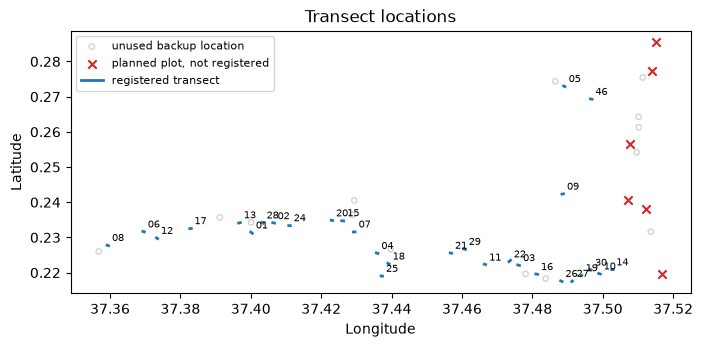

In [13]:
# Planned locations: centroids.geometry is an ODK geopoint "lat lon altitude accuracy"
pts = (df_centroids["geometry"]
       .str.split(expand=True).astype(float)
       .set_axis(["lat", "lon", "altitude", "accuracy"], axis=1))
is_registered = df_centroids["__id"].isin(registered)
is_missing = ~is_registered & (df_centroids["sample_status"] == "primary")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(pts.loc[~is_registered & ~is_missing, "lon"], pts.loc[~is_registered & ~is_missing, "lat"],
           s=15, facecolors="none", edgecolors="lightgrey", label="unused backup location")
ax.scatter(pts.loc[is_missing, "lon"], pts.loc[is_missing, "lat"], marker="x", color="C3", label="planned plot, not registered")

P = "plot_metadata-collect_points-"
for _, r in df_reg.dropna(subset=[f"{P}midpoint-location_midpoint-Latitude"]).iterrows():
    ax.plot([r[f"{P}endpoint_a-location_endpoint_a-Longitude"], r[f"{P}endpoint_b-location_endpoint_b-Longitude"]],
            [r[f"{P}endpoint_a-location_endpoint_a-Latitude"], r[f"{P}endpoint_b-location_endpoint_b-Latitude"]],
            color="C0", lw=2)
    ax.annotate(plot_name[r["plot_selection-selected_plot_uuid"]].split("_")[-1],
                (r[f"{P}midpoint-location_midpoint-Longitude"], r[f"{P}midpoint-location_midpoint-Latitude"]),
                xytext=(3, 3), textcoords="offset points", fontsize=7)
ax.plot([], [], color="C0", lw=2, label="registered transect")
ax.set(xlabel="Longitude", ylabel="Latitude", title="Transect locations")
ax.set_aspect("equal")
ax.legend(fontsize=8)